# Multinomial Logistic Regression From Scratch (TF-IDF)

This notebook rebuilds the paper-category classifier from split datasets using:
- TF-IDF text features
- Multinomial logistic regression
- Validation-based hyperparameter selection
- Visualizations for data, training process, and output quality

Sections follow an implementation-first structure with executable checks.

## 1) Set Up Environment and Dependencies

Import required libraries, set plotting style, and show key package versions.

In [13]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="notebook")

print(f"Python-ready notebook. scikit-learn version: {sklearn.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"seaborn version: {sns.__version__}")

Python-ready notebook. scikit-learn version: 1.8.0
pandas version: 2.3.3
seaborn version: 0.13.2


## 2) Define Project Configuration

Create a typed configuration object for paths and modeling parameters, then validate required split files.

In [2]:
@dataclass
class ProjectConfig:
    splits_dir: Path = Path("data/splits")
    output_dir: Path = Path("models/tfidf_scratch")
    c_grid: Tuple[float, ...] = (0.25, 0.5, 1.0, 2.0, 4.0)
    max_iter: int = 4000
    random_state: int = RANDOM_STATE

    # Keep aligned with the existing production TF-IDF recipe.
    vectorizer_params: Dict[str, object] = None

    def __post_init__(self) -> None:
        if self.vectorizer_params is None:
            self.vectorizer_params = {
                "lowercase": True,
                "ngram_range": (1, 2),
                "min_df": 3,
                "max_df": 0.95,
                "sublinear_tf": True,
                "strip_accents": "unicode",
            }


cfg = ProjectConfig()
cfg.output_dir.mkdir(parents=True, exist_ok=True)

required_files = {
    "train": cfg.splits_dir / "train_papers.csv",
    "val": cfg.splits_dir / "val_papers.csv",
    "test": cfg.splits_dir / "test_papers.csv",
}

missing = [name for name, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing required split files: {missing}")

print("Configuration validated.")
print(cfg)

Configuration validated.
ProjectConfig(splits_dir=PosixPath('data/splits'), output_dir=PosixPath('models/tfidf_scratch'), c_grid=(0.25, 0.5, 1.0, 2.0, 4.0), max_iter=4000, random_state=42, vectorizer_params={'lowercase': True, 'ngram_range': (1, 2), 'min_df': 3, 'max_df': 0.95, 'sublinear_tf': True, 'strip_accents': 'unicode'})


## 3) Create Core Data Structures

Define reusable dataclasses for split data and model outputs, then load and inspect split datasets.

In [14]:
@dataclass
class SplitData:
    train: pd.DataFrame
    val: pd.DataFrame
    test: pd.DataFrame


@dataclass
class TrainArtifacts:
    label_encoder: LabelEncoder
    vectorizer: TfidfVectorizer
    model: object
    best_c: float
    val_results: pd.DataFrame
    history_by_c: Dict[float, pd.DataFrame]


def load_splits(config: ProjectConfig) -> SplitData:
    train_df = pd.read_csv(config.splits_dir / "train_papers.csv")
    val_df = pd.read_csv(config.splits_dir / "val_papers.csv")
    test_df = pd.read_csv(config.splits_dir / "test_papers.csv")

    for name, df in {"train": train_df, "val": val_df, "test": test_df}.items():
        needed = {"model_text", "label"}
        missing_cols = needed.difference(df.columns)
        if missing_cols:
            raise ValueError(f"{name} split missing columns: {sorted(missing_cols)}")

    return SplitData(train=train_df, val=val_df, test=test_df)


splits = load_splits(cfg)
print("Loaded split sizes:")
print({"train": len(splits.train), "val": len(splits.val), "test": len(splits.test)})
display(splits.train.head(3))

Loaded split sizes:
{'train': 1998, 'val': 428, 'test': 429}


,label,title,abstract,arxiv_id,primary_category,categories,published,arxiv_url,topic,list_name,found_in_arxiv_api,source_dataset,model_text,title_norm,abstract_norm,text_fingerprint,title_length,abstract_length,published_year
0,SURVEY,The Modern Mathematics of Deep Learning,We describe the new field of mathematical anal...,2105.04026,cs.LG,cs.LG stat.ML,2021-05-09T21:30:42Z,http://arxiv.org/abs/2105.04026v2,Deep Learning General Methods,The ML,1.0,survey,The Modern Mathematics of Deep Learning We des...,the modern mathematics of deep learning,we describe the new field of mathematical anal...,913d45a5f71a571345ed129630c0426f,6,124,2021
1,SURVEY,Graph Self-Supervised Learning: A Survey,Deep learning on graphs has attracted signific...,2103.00111,cs.LG,cs.LG,2021-02-27T03:04:21Z,http://arxiv.org/abs/2103.00111v5,Graph Neural Networks,The ML,1.0,survey,Graph Self-Supervised Learning: A Survey Deep ...,graph self-supervised learning: a survey,deep learning on graphs has attracted signific...,57b73170bc411e753b403e98df46dc41,5,188,2021
2,APPLIED,GUI-CEval: A Hierarchical and Comprehensive Ch...,Recent progress in Multimodal Large Language M...,2603.15039v1,cs.CV,cs.CV,2026-03-16T09:45:33Z,http://arxiv.org/abs/2603.15039v1,NaN,NaN,NaN,applied,GUI-CEval: A Hierarchical and Comprehensive Ch...,gui-ceval: a hierarchical and comprehensive ch...,recent progress in multimodal large language m...,f8240a0f794f239ab7ca1182ef2c95d6,11,200,2026


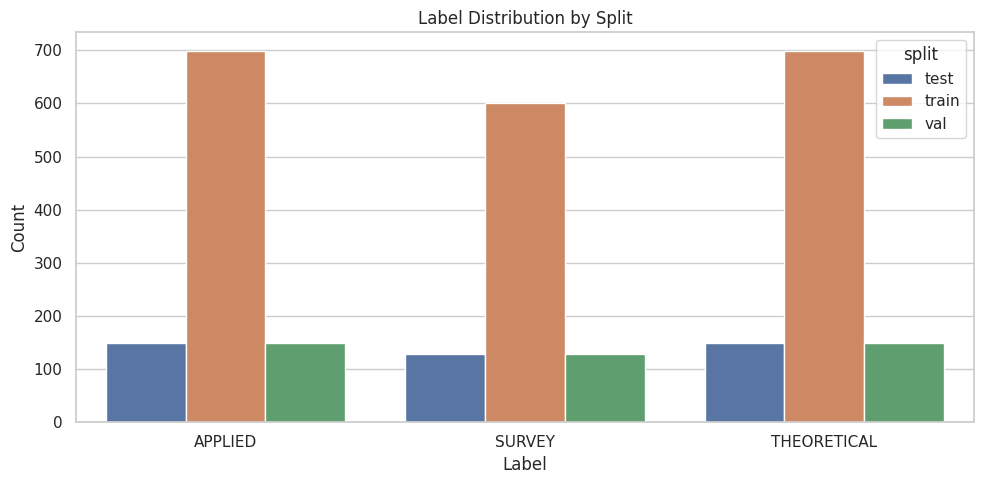

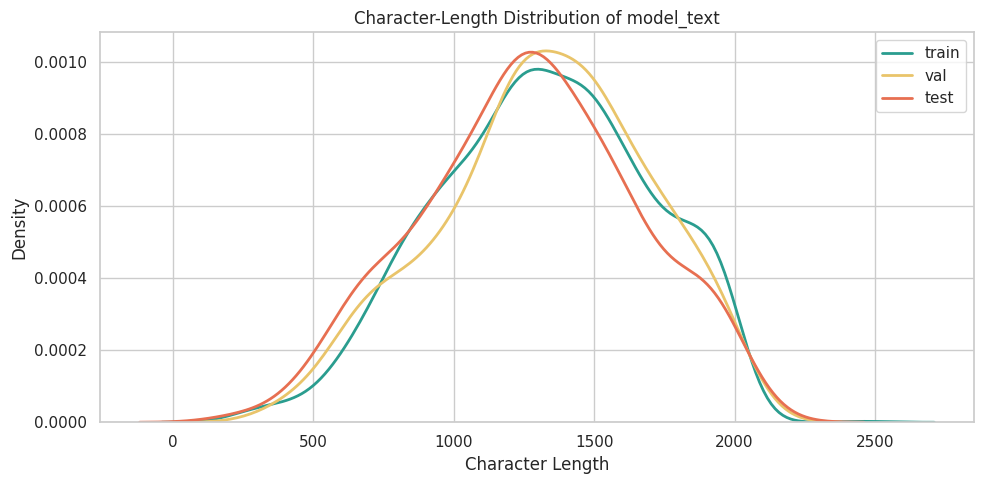

In [4]:
# Visualize class distributions across splits.
label_counts = (
    pd.concat(
        [
            splits.train.assign(split="train"),
            splits.val.assign(split="val"),
            splits.test.assign(split="test"),
        ],
        ignore_index=True,
    )
    .groupby(["split", "label"], as_index=False)
    .size()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=label_counts, x="label", y="size", hue="split")
plt.title("Label Distribution by Split")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Visualize model_text length distribution as a quick input variability check.
length_df = pd.concat(
    [
        splits.train[["model_text"]].assign(split="train"),
        splits.val[["model_text"]].assign(split="val"),
        splits.test[["model_text"]].assign(split="test"),
    ],
    ignore_index=True,
)
length_df["char_len"] = length_df["model_text"].fillna("").str.len()

plt.figure(figsize=(10, 5))
for split_name, color in [("train", "#2a9d8f"), ("val", "#e9c46a"), ("test", "#e76f51")]:
    sns.kdeplot(
        data=length_df[length_df["split"] == split_name],
        x="char_len",
        label=split_name,
        fill=False,
        linewidth=2,
        color=color,
    )
plt.title("Character-Length Distribution of model_text")
plt.xlabel("Character Length")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 4) Implement Main Processing Function (Mathematics-First)

We now train multinomial logistic regression from scratch using NumPy:

$$
z = XW + b,
\quad
p = \text{softmax}(z),
\quad
\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{K} y_{ik}\log p_{ik} + \frac{\lambda}{2}\|W\|_2^2
$$

Gradients:

$$
\frac{\partial \mathcal{L}}{\partial W} = \frac{1}{N}X^\top(p-y) + \lambda W,
\quad
\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)
$$

Update rule (gradient descent):

$$
W \leftarrow W - \eta \frac{\partial \mathcal{L}}{\partial W},
\quad
b \leftarrow b - \eta \frac{\partial \mathcal{L}}{\partial b}
$$

In [16]:
class MultinomialLogRegScratch:
    def __init__(
        self,
        n_features: int,
        n_classes: int,
        learning_rate: float = 0.8,
        n_epochs: int = 220,
        reg_lambda: float = 1e-4,
        random_state: int = 42,
    ) -> None:
        self.n_features = n_features
        self.n_classes = n_classes
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.reg_lambda = reg_lambda
        self.random_state = random_state

        rng = np.random.default_rng(self.random_state)
        self.W = rng.normal(loc=0.0, scale=0.01, size=(n_features, n_classes))
        self.b = np.zeros((1, n_classes), dtype=np.float64)
        self.history_: List[Dict[str, float]] = []

    @staticmethod
    def _softmax(logits: np.ndarray) -> np.ndarray:
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_shifted = np.exp(shifted)
        return exp_shifted / exp_shifted.sum(axis=1, keepdims=True)

    @staticmethod
    def _one_hot(y: np.ndarray, n_classes: int) -> np.ndarray:
        y_one_hot = np.zeros((y.shape[0], n_classes), dtype=np.float64)
        y_one_hot[np.arange(y.shape[0]), y] = 1.0
        return y_one_hot

    def _forward(self, X) -> np.ndarray:
        return (X @ self.W) + self.b

    def _loss_and_grads(self, X, y: np.ndarray) -> Tuple[float, np.ndarray, np.ndarray]:
        n = X.shape[0]
        logits = self._forward(X)
        probs = self._softmax(logits)
        y_one_hot = self._one_hot(y, self.n_classes)

        eps = 1e-12
        data_loss = -np.mean(np.sum(y_one_hot * np.log(probs + eps), axis=1))
        reg_loss = 0.5 * self.reg_lambda * np.sum(self.W * self.W)
        loss = data_loss + reg_loss

        d_logits = (probs - y_one_hot) / n
        grad_W = (X.T @ d_logits) + self.reg_lambda * self.W
        grad_b = np.sum(d_logits, axis=0, keepdims=True)

        return loss, grad_W, grad_b

    def fit(self, X, y: np.ndarray, X_val=None, y_val=None) -> "MultinomialLogRegScratch":
        y = np.asarray(y, dtype=int)

        for epoch in range(1, self.n_epochs + 1):
            train_loss, grad_W, grad_b = self._loss_and_grads(X, y)
            self.W -= self.learning_rate * grad_W
            self.b -= self.learning_rate * grad_b

            if epoch == 1 or epoch % 20 == 0 or epoch == self.n_epochs:
                train_pred = self.predict(X)
                train_acc = float((train_pred == y).mean())
                row = {
                    "epoch": float(epoch),
                    "train_loss": float(train_loss),
                    "train_acc": train_acc,
                }
                if X_val is not None and y_val is not None:
                    val_pred = self.predict(X_val)
                    val_macro_f1 = float(f1_score(y_val, val_pred, average="macro"))
                    row["val_macro_f1"] = val_macro_f1
                self.history_.append(row)

        return self

    def predict_proba(self, X) -> np.ndarray:
        logits = self._forward(X)
        return self._softmax(logits)

    def predict(self, X) -> np.ndarray:
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


def train_with_validation(config: ProjectConfig, split_data: SplitData) -> TrainArtifacts:
    label_encoder = LabelEncoder()
    y_train = label_encoder.fit_transform(split_data.train["label"])
    y_val = label_encoder.transform(split_data.val["label"])

    vectorizer = TfidfVectorizer(**config.vectorizer_params)
    X_train = vectorizer.fit_transform(split_data.train["model_text"].fillna(""))
    X_val = vectorizer.transform(split_data.val["model_text"].fillna(""))

    rows: List[Dict[str, float]] = []
    history_by_c: Dict[float, pd.DataFrame] = {}
    best_c = None
    best_macro_f1 = -1.0
    best_model = None

    for c_value in config.c_grid:
        # For this objective, scale regularization similarly to common averaged-loss forms.
        reg_lambda = 1.0 / (c_value * X_train.shape[0])
        candidate = MultinomialLogRegScratch(
            n_features=X_train.shape[1],
            n_classes=len(label_encoder.classes_),
            learning_rate=0.8,
            n_epochs=220,
            reg_lambda=reg_lambda,
            random_state=config.random_state,
        )
        candidate.fit(X_train, y_train, X_val=X_val, y_val=y_val)
        val_pred = candidate.predict(X_val)
        macro_f1 = f1_score(y_val, val_pred, average="macro")

        rows.append({"C": c_value, "val_macro_f1": float(macro_f1)})
        history_by_c[float(c_value)] = pd.DataFrame(candidate.history_)

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_c = c_value
            best_model = candidate

    val_results = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)

    return TrainArtifacts(
        label_encoder=label_encoder,
        vectorizer=vectorizer,
        model=best_model,
        best_c=float(best_c),
        val_results=val_results,
        history_by_c=history_by_c,
    )


artifacts = train_with_validation(cfg, splits)
display(artifacts.val_results)

,C,val_macro_f1
0,0.25,0.947723
1,0.50,0.947723
2,1.00,0.947723
3,2.00,0.947723
4,4.00,0.947723


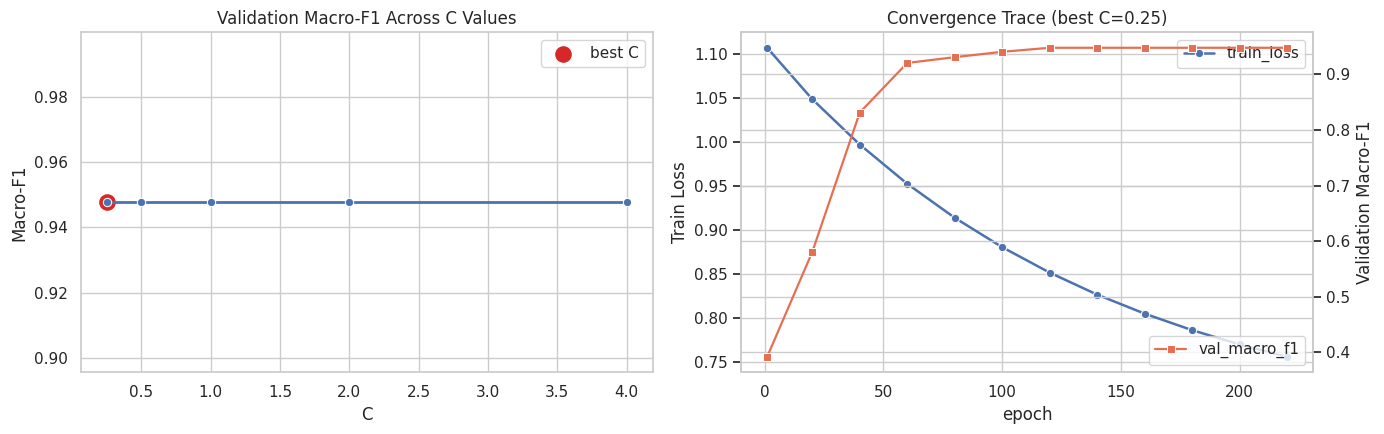

In [17]:
# Visualize hyperparameter search and best-model convergence.
val_plot_df = artifacts.val_results.sort_values("C")
best_row = artifacts.val_results.iloc[0]
best_history = artifacts.history_by_c[float(best_row["C"])]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.lineplot(data=val_plot_df, x="C", y="val_macro_f1", marker="o", linewidth=2, ax=axes[0])
axes[0].scatter([best_row["C"]], [best_row["val_macro_f1"]], s=120, color="#d62828", label="best C")
axes[0].set_title("Validation Macro-F1 Across C Values")
axes[0].set_ylabel("Macro-F1")
axes[0].legend()

sns.lineplot(data=best_history, x="epoch", y="train_loss", marker="o", linewidth=1.8, ax=axes[1], label="train_loss")
if "val_macro_f1" in best_history.columns:
    ax2 = axes[1].twinx()
    sns.lineplot(data=best_history, x="epoch", y="val_macro_f1", marker="s", linewidth=1.6, ax=ax2, color="#e76f51", label="val_macro_f1")
    ax2.set_ylabel("Validation Macro-F1")
axes[1].set_title(f"Convergence Trace (best C={best_row['C']})")
axes[1].set_ylabel("Train Loss")

plt.tight_layout()
plt.show()

## 5) Add Input Validation and Error Handling

Validate expected fields and show a controlled failure case for missing columns.

In [7]:
def validate_input_frame(df: pd.DataFrame, frame_name: str) -> None:
    required = {"model_text", "label"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{frame_name} missing required columns: {sorted(missing)}")

    if df["model_text"].isna().all():
        raise ValueError(f"{frame_name} has all-empty model_text.")


# Controlled failure demonstration.
try:
    bad_df = splits.train[["label"]].copy()
    validate_input_frame(bad_df, "bad_df")
except ValueError as exc:
    print(f"Expected validation error: {exc}")

# Positive path.
validate_input_frame(splits.train, "train")
print("Input validation succeeded for train split.")

Expected validation error: bad_df missing required columns: ['model_text']
Input validation succeeded for train split.


## 6) Run a Minimal End-to-End Execution

Refit on train+val with best C, evaluate on test, visualize outputs, and persist artifacts.

In [18]:
def train_final_and_evaluate(config: ProjectConfig, split_data: SplitData, best_c: float):
    train_val_df = pd.concat([split_data.train, split_data.val], ignore_index=True)

    final_encoder = LabelEncoder()
    y_train_val = final_encoder.fit_transform(train_val_df["label"])
    y_test = final_encoder.transform(split_data.test["label"])

    final_vectorizer = TfidfVectorizer(**config.vectorizer_params)
    X_train_val = final_vectorizer.fit_transform(train_val_df["model_text"].fillna(""))
    X_test = final_vectorizer.transform(split_data.test["model_text"].fillna(""))

    final_model = MultinomialLogRegScratch(
        n_features=X_train_val.shape[1],
        n_classes=len(final_encoder.classes_),
        learning_rate=0.8,
        n_epochs=280,
        reg_lambda=1.0 / (float(best_c) * X_train_val.shape[0]),
        random_state=config.random_state,
    )
    final_model.fit(X_train_val, y_train_val)
    y_pred = final_model.predict(X_test)

    metrics = {
        "best_c": float(best_c),
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "test_macro_f1": float(f1_score(y_test, y_pred, average="macro")),
        "test_weighted_f1": float(f1_score(y_test, y_pred, average="weighted")),
    }

    report_df = pd.DataFrame(
        classification_report(
            y_test,
            y_pred,
            target_names=final_encoder.classes_,
            output_dict=True,
            digits=4,
        )
    ).transpose()

    cm = confusion_matrix(y_test, y_pred)

    return {
        "encoder": final_encoder,
        "vectorizer": final_vectorizer,
        "model": final_model,
        "y_test": y_test,
        "y_pred": y_pred,
        "metrics": metrics,
        "report_df": report_df,
        "confusion_matrix": cm,
        "classes": list(final_encoder.classes_),
        "fit_history": pd.DataFrame(final_model.history_),
    }


final_outputs = train_final_and_evaluate(cfg, splits, artifacts.best_c)
print(final_outputs["metrics"])
display(final_outputs["report_df"])

{'best_c': 0.25, 'test_accuracy': 0.9673659673659674, 'test_macro_f1': 0.9680630283999115, 'test_weighted_f1': 0.9674520351777256}


,precision,recall,f1-score,support
APPLIED,0.941558,0.966667,0.953947,150.000000
SURVEY,0.984375,0.976744,0.980545,129.000000
THEORETICAL,0.979592,0.960000,0.969697,150.000000
accuracy,0.967366,0.967366,0.967366,0.967366
macro avg,0.968508,0.967804,0.968063,429.000000
weighted avg,0.967732,0.967366,0.967452,429.000000


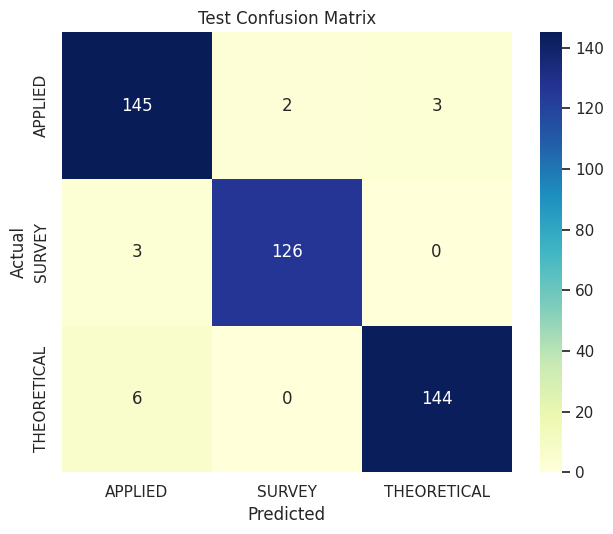

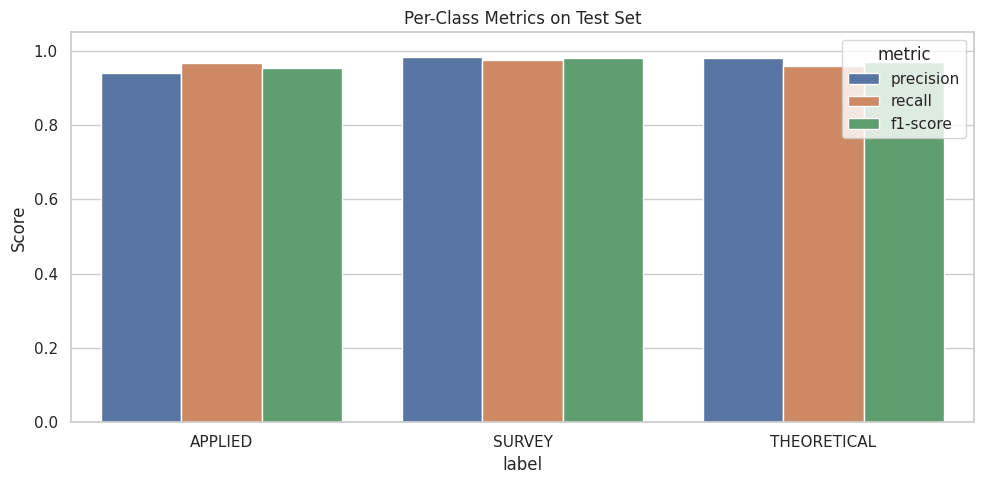

In [19]:
# Output visualization 1: confusion matrix heatmap.
plt.figure(figsize=(6.5, 5.5))
sns.heatmap(
    final_outputs["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=final_outputs["classes"],
    yticklabels=final_outputs["classes"],
)
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Output visualization 2: per-class precision/recall/F1.
class_report = final_outputs["report_df"].loc[final_outputs["classes"], ["precision", "recall", "f1-score"]]
plot_df = class_report.reset_index().melt(id_vars="index", var_name="metric", value_name="score")
plot_df = plot_df.rename(columns={"index": "label"})

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="label", y="score", hue="metric")
plt.title("Per-Class Metrics on Test Set")
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.tight_layout()
plt.show()

In [20]:
# Persist artifacts to a dedicated output folder.
joblib.dump(final_outputs["encoder"], cfg.output_dir / "label_encoder.joblib")
joblib.dump(final_outputs["vectorizer"], cfg.output_dir / "tfidf_vectorizer.joblib")
joblib.dump(final_outputs["model"], cfg.output_dir / "tfidf_logreg.joblib")

artifacts.val_results.to_csv(cfg.output_dir / "tfidf_val_results.csv", index=False)
final_outputs["report_df"].to_csv(cfg.output_dir / "tfidf_classification_report.csv")

with open(cfg.output_dir / "tfidf_metrics.json", "w", encoding="utf-8") as f:
    json.dump(final_outputs["metrics"], f, indent=2)

print(f"Artifacts written to: {cfg.output_dir}")
print(sorted([p.name for p in cfg.output_dir.iterdir()]))

Artifacts written to: models/tfidf_scratch
['label_encoder.joblib', 'tfidf_classification_report.csv', 'tfidf_logreg.joblib', 'tfidf_metrics.json', 'tfidf_val_results.csv', 'tfidf_vectorizer.joblib']


In [21]:
# Smoke prediction example using title + abstract formatting.
def build_model_text(title: str, abstract: str) -> str:
    return f"{(title or '').strip()} {(abstract or '').strip()}".strip()

sample_text = build_model_text(
    title="A survey of transformer-based methods for information retrieval",
    abstract="We summarize recent architectures, benchmarks, and practical findings across retrieval tasks.",
)

sample_vec = final_outputs["vectorizer"].transform([sample_text])
proba = final_outputs["model"].predict_proba(sample_vec)[0]
order = np.argsort(proba)[::-1]

top_k = 3
top_predictions = [
    {
        "label": final_outputs["encoder"].classes_[i],
        "probability": float(proba[i]),
    }
    for i in order[:top_k]
]

pred_label = final_outputs["encoder"].classes_[order[0]]
print({"predicted_label": pred_label, "top_probabilities": top_predictions})

{'predicted_label': 'SURVEY', 'top_probabilities': [{'label': 'SURVEY', 'probability': 0.4030478484806929}, {'label': 'APPLIED', 'probability': 0.3641368102074597}, {'label': 'THEORETICAL', 'probability': 0.2328153413118474}]}


## 7) Advanced Optimization Experiments

This section adds three deeper experiments:
1. Mini-batch gradient descent (MBGD) with learning-rate scheduling
2. Finite-difference gradient checking (numerical vs analytical derivatives)
3. Vectorized second-order update via a diagonal Newton approximation

These experiments use the same TF-IDF features and label encoding for fair comparison.

In [26]:
def _to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)


def _softmax(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_shifted = np.exp(shifted)
    return exp_shifted / exp_shifted.sum(axis=1, keepdims=True)


def _one_hot(y: np.ndarray, n_classes: int) -> np.ndarray:
    y_oh = np.zeros((y.shape[0], n_classes), dtype=np.float64)
    y_oh[np.arange(y.shape[0]), y] = 1.0
    return y_oh


def _loss_grads_diag_hessian(
    X,
    y: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    reg_lambda: float,
) -> Tuple[float, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    n = X.shape[0]
    logits = (X @ W) + b
    probs = _softmax(logits)
    y_oh = _one_hot(y, W.shape[1])

    eps = 1e-12
    loss = -np.mean(np.sum(y_oh * np.log(probs + eps), axis=1)) + 0.5 * reg_lambda * np.sum(W * W)

    d_logits = (probs - y_oh) / n
    grad_W = (X.T @ d_logits) + reg_lambda * W
    grad_b = np.sum(d_logits, axis=0, keepdims=True)

    # Diagonal Hessian approximation for softmax CE: p*(1-p).
    var_term = probs * (1.0 - probs)
    X_sq = X.multiply(X) if hasattr(X, "multiply") else (X * X)
    h_diag_W = (X_sq.T @ var_term) / n + reg_lambda
    h_diag_b = np.mean(var_term, axis=0, keepdims=True)

    return float(loss), grad_W, grad_b, np.asarray(h_diag_W), np.asarray(h_diag_b)


def run_optimizer_experiment(
    X_train,
    y_train: np.ndarray,
    X_val,
    y_val: np.ndarray,
    method: str = "mbgd",
    n_epochs: int = 80,
    batch_size: int = 128,
    lr0: float = 0.8,
    lr_decay: float = 0.03,
    reg_lambda: float = 1e-4,
    newton_damping: float = 1e-2,
    step_clip: float = 1.5,
    random_state: int = 42,
) -> Dict[str, object]:
    n_samples, n_features = X_train.shape
    n_classes = len(np.unique(y_train))
    rng = np.random.default_rng(random_state)

    W = rng.normal(0.0, 0.01, size=(n_features, n_classes))
    b = np.zeros((1, n_classes), dtype=np.float64)
    history = []

    for epoch in range(1, n_epochs + 1):
        eta = lr0 / (1.0 + lr_decay * (epoch - 1))
        indices = rng.permutation(n_samples)

        for start in range(0, n_samples, batch_size):
            batch_idx = indices[start : start + batch_size]
            Xb = X_train[batch_idx]
            yb = y_train[batch_idx]

            _, grad_W, grad_b, hW_diag, hb_diag = _loss_grads_diag_hessian(Xb, yb, W, b, reg_lambda)

            if method == "mbgd":
                W -= eta * grad_W
                b -= eta * grad_b
            elif method == "newton_diag":
                # Damped diagonal Newton step with clipping for stability.
                step_W = grad_W / (hW_diag + newton_damping)
                step_b = grad_b / (hb_diag + newton_damping)
                step_W = np.clip(step_W, -step_clip, step_clip)
                step_b = np.clip(step_b, -step_clip, step_clip)
                W -= eta * step_W
                b -= eta * step_b
            else:
                raise ValueError("Unknown method. Use 'mbgd' or 'newton_diag'.")

        train_loss, _, _, _, _ = _loss_grads_diag_hessian(X_train, y_train, W, b, reg_lambda)
        val_logits = (X_val @ W) + b
        val_pred = np.argmax(_softmax(val_logits), axis=1)
        val_macro_f1 = float(f1_score(y_val, val_pred, average="macro"))

        history.append(
            {
                "epoch": epoch,
                "lr": eta,
                "train_loss": train_loss,
                "val_macro_f1": val_macro_f1,
                "method": method,
            }
        )

    return {
        "W": W,
        "b": b,
        "history": pd.DataFrame(history),
    }

In [24]:
# Gradient checking on a tiny subset and small parameter block.
X_gc_sparse = artifacts.vectorizer.transform(splits.train["model_text"].fillna("").iloc[:20])
X_gc = _to_dense(X_gc_sparse[:, :60])
y_gc = artifacts.label_encoder.transform(splits.train["label"].iloc[:20])

rng_gc = np.random.default_rng(123)
W_gc = rng_gc.normal(0.0, 0.01, size=(X_gc.shape[1], len(artifacts.label_encoder.classes_)))
b_gc = np.zeros((1, len(artifacts.label_encoder.classes_)), dtype=np.float64)
reg_gc = 1e-3

_, gradW_analytic, gradb_analytic, _, _ = _loss_grads_diag_hessian(X_gc, y_gc, W_gc, b_gc, reg_gc)

def _loss_only(X, y, W, b, reg_lambda):
    logits = (X @ W) + b
    probs = _softmax(logits)
    y_oh = _one_hot(y, W.shape[1])
    eps = 1e-12
    return -np.mean(np.sum(y_oh * np.log(probs + eps), axis=1)) + 0.5 * reg_lambda * np.sum(W * W)

# Check a handful of random coordinates for W and b.
eps_fd = 1e-5
check_pairs_W = [(rng_gc.integers(W_gc.shape[0]), rng_gc.integers(W_gc.shape[1])) for _ in range(10)]
check_pairs_b = [rng_gc.integers(b_gc.shape[1]) for _ in range(3)]

rel_errors_W = []
for i, j in check_pairs_W:
    W_plus = W_gc.copy()
    W_minus = W_gc.copy()
    W_plus[i, j] += eps_fd
    W_minus[i, j] -= eps_fd
    num_grad = (_loss_only(X_gc, y_gc, W_plus, b_gc, reg_gc) - _loss_only(X_gc, y_gc, W_minus, b_gc, reg_gc)) / (2.0 * eps_fd)
    ana_grad = gradW_analytic[i, j]
    rel_err = abs(num_grad - ana_grad) / max(1e-12, abs(num_grad) + abs(ana_grad))
    rel_errors_W.append(rel_err)

rel_errors_b = []
for j in check_pairs_b:
    b_plus = b_gc.copy()
    b_minus = b_gc.copy()
    b_plus[0, j] += eps_fd
    b_minus[0, j] -= eps_fd
    num_grad = (_loss_only(X_gc, y_gc, W_gc, b_plus, reg_gc) - _loss_only(X_gc, y_gc, W_gc, b_minus, reg_gc)) / (2.0 * eps_fd)
    ana_grad = gradb_analytic[0, j]
    rel_err = abs(num_grad - ana_grad) / max(1e-12, abs(num_grad) + abs(ana_grad))
    rel_errors_b.append(rel_err)

print("Gradient check (W) max relative error:", float(np.max(rel_errors_W)))
print("Gradient check (b) max relative error:", float(np.max(rel_errors_b)))
print("Rule of thumb: < 1e-4 is generally good for finite-difference checks.")

Gradient check (W) max relative error: 8.560723306996252e-07
Gradient check (b) max relative error: 9.149942487604119e-11
Rule of thumb: < 1e-4 is generally good for finite-difference checks.


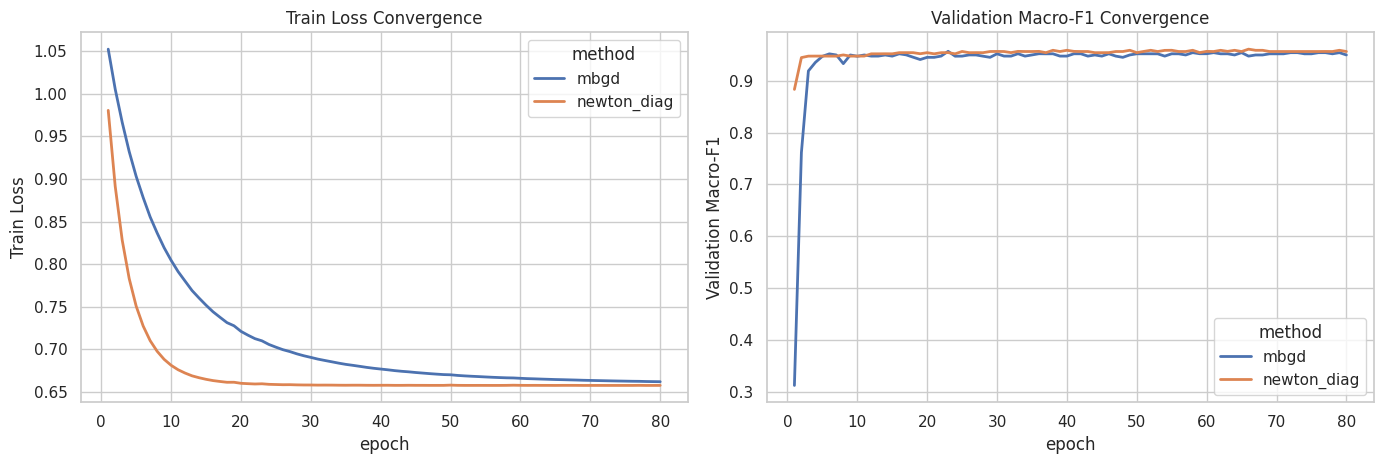

,method,final_train_loss,final_val_macro_f1,best_val_macro_f1
1,newton_diag,0.657612,0.956542,0.961116
0,mbgd,0.661959,0.949874,0.956913


In [27]:
# Compare mini-batch GD + LR scheduling vs damped diagonal Newton approximation.
X_train_adv = artifacts.vectorizer.transform(splits.train["model_text"].fillna(""))
X_val_adv = artifacts.vectorizer.transform(splits.val["model_text"].fillna(""))
y_train_adv = artifacts.label_encoder.transform(splits.train["label"])
y_val_adv = artifacts.label_encoder.transform(splits.val["label"])

adv_reg_lambda = 1.0 / (float(artifacts.best_c) * X_train_adv.shape[0])

mbgd_run = run_optimizer_experiment(
    X_train=X_train_adv,
    y_train=y_train_adv,
    X_val=X_val_adv,
    y_val=y_val_adv,
    method="mbgd",
    n_epochs=80,
    batch_size=128,
    lr0=0.9,
    lr_decay=0.03,
    reg_lambda=adv_reg_lambda,
    random_state=42,
)

newton_diag_run = run_optimizer_experiment(
    X_train=X_train_adv,
    y_train=y_train_adv,
    X_val=X_val_adv,
    y_val=y_val_adv,
    method="newton_diag",
    n_epochs=80,
    batch_size=128,
    lr0=0.12,
    lr_decay=0.01,
    reg_lambda=adv_reg_lambda,
    newton_damping=5e-2,
    step_clip=1.0,
    random_state=42,
)

comparison_hist = pd.concat([mbgd_run["history"], newton_diag_run["history"]], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(data=comparison_hist, x="epoch", y="train_loss", hue="method", linewidth=2, ax=axes[0])
axes[0].set_title("Train Loss Convergence")
axes[0].set_ylabel("Train Loss")

sns.lineplot(data=comparison_hist, x="epoch", y="val_macro_f1", hue="method", linewidth=2, ax=axes[1])
axes[1].set_title("Validation Macro-F1 Convergence")
axes[1].set_ylabel("Validation Macro-F1")

plt.tight_layout()
plt.show()

summary_adv = (
    comparison_hist.groupby("method", as_index=False)
    .agg(final_train_loss=("train_loss", "last"), final_val_macro_f1=("val_macro_f1", "last"), best_val_macro_f1=("val_macro_f1", "max"))
    .sort_values("best_val_macro_f1", ascending=False)
)
display(summary_adv)

## 7) Add Basic Unit Tests

Run lightweight assertions to verify expected behavior and edge-case handling.

In [22]:
def run_notebook_tests() -> None:
    assert len(artifacts.val_results) == len(cfg.c_grid), "Validation results should include one row per C."
    assert set(artifacts.val_results.columns) == {"C", "val_macro_f1"}, "Unexpected validation schema."

    # From-scratch optimizer should show non-increasing trend in training loss overall.
    best_c = float(artifacts.val_results.iloc[0]["C"])
    hist = artifacts.history_by_c[best_c]
    assert {"epoch", "train_loss"}.issubset(hist.columns), "Missing optimization history columns."
    assert hist.iloc[-1]["train_loss"] < hist.iloc[0]["train_loss"], "Training loss did not decrease."

    m = final_outputs["metrics"]
    for key in ["test_accuracy", "test_macro_f1", "test_weighted_f1"]:
        assert 0.0 <= m[key] <= 1.0, f"Metric {key} is outside [0, 1]."

    assert final_outputs["confusion_matrix"].shape == (3, 3), "Expected 3x3 confusion matrix."
    assert (cfg.output_dir / "tfidf_logreg.joblib").exists(), "Missing exported model artifact."

    text = build_model_text("Title", "Abstract")
    assert text == "Title Abstract", "model_text formatting mismatch."

    print("All notebook tests passed.")


run_notebook_tests()

All notebook tests passed.
